In [1]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
import commondefs as myF
from mpl_toolkits.basemap import Basemap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams.update({'font.size': 10})

In [2]:
mydir = '../processed_netcdf/'

In [3]:
def is_feb(month):
    return month==2

def is_sep(month):
    return month==9

In [4]:
moddir = '../processed_netcdf/CMIP6_sic_1979-2018/'
allfiles = sorted([f for f in os.listdir(moddir) if 'siconc_SImon' in f])
modnames = [f.split('_')[2] for f in allfiles]

incnames = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_historical_r1_updated.nc').name.values
incnames  = [f.strip().split('_')[0] for f in incnames]
modnames = [f for f in modnames if f in incnames]


obsdir='../processed_netcdf/OBS_sic_1979-2018/'
obsnames = ['Bootstrap','NASA-Team','osisaf']
modnames = sorted(list(set(modnames)))
nobs = len(obsnames)
names = obsnames+ modnames
print(names)
nmod = len(names)
print(len(names))

['Bootstrap', 'NASA-Team', 'osisaf', 'ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'UKESM1-0-LL']
32


In [5]:
maps = [Basemap(projection='npstere', boundinglat=55, lon_0 = 0),Basemap(projection='spstere', boundinglat=-55, lon_0 = 180)]

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.
  """Entry point for launching an IPython kernel.


In [ ]:
listds = []
lats = []
lons = []

for n,name in enumerate(names):
    
    if n<nobs:
        mydir = obsdir
    else:
        mydir = moddir
    ensfiles = [f for f in os.listdir(mydir) if name+'_' in f][0]
    print(ensfiles[:-3])
    ds = xr.open_dataset(mydir+ensfiles, chunks={'time': 12})
    if 'siconc' not in ds:
        if 'sic' in ds:
            ds = ds.rename({'sic':'siconc'})
        elif 'seaice' in ds:
            ds = ds.rename({'seaice':'siconc'})
        ds.siconc.values = 100.*ds.siconc.values
    
    ds.siconc.values = ds.siconc.where(ds.siconc<=100.)
    print(name,np.nanmax(ds.siconc.values))
    ds = myF.lat_renamer(ds)
    listds.append(ds)
    lat,lon = myF.get_lats(ds)
    lats.append(lat)
    lons.append(lon)
    
    monds = []
    for ct,month in enumerate([1,8]):
        if month==1:
            mydata = ds.sel(time=is_feb(listds[mod]['time.month'])).siconc
        elif month==8:
            mydata = ds.sel(time=is_sep(listds[mod]['time.month'])).siconc
            
        trend_mod, _, rval, pval, std_err = myF.linregress(np.arange(40),mydata,dim='time')
        
        trend_mod = trend_mod.to_dataset(name='siconc_trend')
        pval = pval.to_dataset(name='siconc_pval')
        rval = rval.to_dataset(name='siconc_rval')
        std_err = std_err.to_dataset(name='siconc_stderr')
        
        
        mergeds = xr.merge([mydata.mean(dim='time'),trend_mod,pval,std_err])
        mergeds.attrs = ds.attrs
        mergeds['month'] = month+1
        
        monds.append(mergeds)
    outds = xr.concat(monds,dim='month')
    outds['name'] = names[mod]
    print(outds)
    
    outds.to_netcdf('../processed_netcdf/CMIP6_sic_1979-2018/trends/'+ensfiles[:-3]+'_trend.nc')
    
    

siconc_OBS_Bootstrap_monthly_sh_1979-2018


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in less_equal
  return func(*args2)


Bootstrap 100.0


In [ ]:
%%time
names[2] = 'OSISAF'
years = np.arange(1979,2019,1)
h = 1
for ct,month in enumerate([1,8]):
    fig = plt.figure(figsize=(10,12))
    plt.rcParams.update({'font.size': 10})

    for mod in range(nmod):
        print(names[mod])
        
        if month==1:
            mydata = listds[mod].sel(time=is_feb(listds[mod]['time.month'])).siconc
        elif month==8:
            mydata = listds[mod].sel(time=is_sep(listds[mod]['time.month'])).siconc
        
        ni = len(lats[mod][:,0])
        nj = len(lons[mod][0,:])
        
        trend_mod = np.zeros([ni,nj])
        
        for i in range(int(ni/2)):
            for j in range(nj):
                ydat = mydata.values[:,i,j]
                if not np.all(ydat==0):
                    if (len(ydat[~np.isnan(ydat)])):
                        trend_mod[i,j], _, _, p_value, _ = stats.linregress(years[~np.isnan(ydat)], ydat[~np.isnan(ydat)])
                        #if p_value>0.05:
                        #    trend_mod[i,j] = 0.

        ax = plt.subplot(7,5,mod+1)
        ax.set_title(myF.alphabet[mod]+' '+names[mod],fontsize=10,loc='left')
        m = maps[h]
        x, y = m(lons[mod],lats[mod])

        #mean sea ice contours
        mydata = listds[mod].groupby('time.month').mean(dim='time').siconc[month,:,:].values
        mydata = ma.masked_where(lats[mod]>0,mydata)
        mydata = ma.masked_invalid(mydata)
        mydata = ma.masked_where(mydata<0.1,mydata)
        CS1 = m.contour(x,y,mydata,levels=[15.,80.],linestyles=['--','-'],colors=['black','black','black'])   

        #trends in pcolor
        mydata = trend_mod
        mydata = ma.masked_where(lats[mod]>0,mydata)
        mydata = ma.masked_invalid(mydata)
        print(np.max(mydata*10.),np.min(mydata*10.))
        CS2 = m.pcolor(x,y,10.*mydata,cmap = plt.cm.seismic_r,vmin=-40.,vmax=40.)       
        m.drawcoastlines(color='black')
        m.fillcontinents(color='lightgrey')
        
        
    
    cbar_ax = fig.add_axes([0.5, 0.05, 0.3, 0.025]) #[left, bottom, width, height]
    cbar = fig.colorbar(CS2, cax=cbar_ax,  orientation='horizontal')
    cbar.ax.set_title('Sea ice concentration trend (%/dec)',fontsize=10)
    plt.tight_layout()
    fig.savefig('figS'+str((ct+7)),bbox_inches='tight',dpi=600)
    plt.show()
    plt.close()

In [19]:
%%time
names[2] = 'OSISAF'
h = 1

    
for mod in range(1):#range(nmod):
    print(names[mod])
    
    monds = []
        
    for ct,month in enumerate([1,8]):
        if month==1:
            mydata = listds[mod].sel(time=is_feb(listds[mod]['time.month'])).siconc
        elif month==8:
            mydata = listds[mod].sel(time=is_sep(listds[mod]['time.month'])).siconc
            
        trend_mod, _, _, pval, std_err = myF.linregress(np.arange(40),mydata,dim='time')
        
        trend_mod = trend_mod.to_dataset(name='siconc_trend')
        pval = pval.to_dataset(name='siconc_pval')
        std_err = std_err.to_dataset(name='siconc_stderr')
        
        
        ds = xr.merge([mydata.mean(dim='time'),trend_mod,pval,std_err])
        ds.attrs = listds[mod].attrs
        ds['month'] = month+1#myF.months[month].lower()
        #ds['time'] = np.arange(1979,2019,1)
        #ds = ds.rename({'time':'year'})
        
        monds.append(ds)
    outds = xr.concat(monds,dim='month')
    outds['name'] = names[mod]
    print(outds)

Bootstrap


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/xarray/core/nanops.py:140: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis=axis, dtype=dtype)


<xarray.Dataset>
Dimensions:        (month: 2, xgrid: 316, ygrid: 332)
Coordinates:
    longitude      (ygrid, xgrid) float64 -42.23 -42.05 -41.87 ... 135.2 135.0
    latitude       (ygrid, xgrid) float64 -39.36 -39.49 -39.62 ... -41.72 -41.58
  * ygrid          (ygrid) float32 4337500.0 4312500.0 ... -3912500.0 -3937500.0
  * xgrid          (xgrid) float32 -3937500.0 -3912500.0 ... 3912500.0 3937500.0
  * month          (month) int64 2 9
Data variables:
    siconc         (month, ygrid, xgrid) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    siconc_trend   (month, ygrid, xgrid) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    siconc_pval    (month, ygrid, xgrid) float64 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    siconc_stderr  (month, ygrid, xgrid) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    name           <U9 'Bootstrap'
Attributes:
    CDI:                       Climate Data Interface version 1.9.7.1 (http:/...
    history:                   Mon Oct 07 13:06:58 2019: cdo mulc,100 siconc_...
    sour

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/xarray/core/nanops.py:140: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis=axis, dtype=dtype)


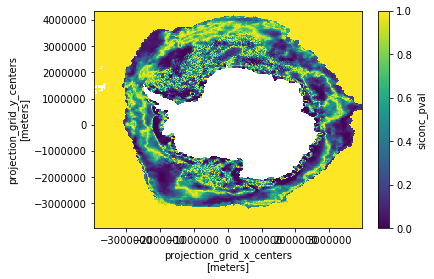

In [13]:
ds.siconc_pval.plot()

In [ ]:
fig = plt.figure(figsize=(10,12))
    plt.rcParams.update({'font.size': 10})
ax = plt.subplot(7,5,mod+1)
        ax.set_title(myF.alphabet[mod]+' '+names[mod],fontsize=10,loc='left')
        m = maps[h]
        x, y = m(lons[mod],lats[mod])

        #mean sea ice contours
        mydata = listds[mod].groupby('time.month').mean(dim='time').siconc[month,:,:].values
        mydata = ma.masked_where(lats[mod]>0,mydata)
        mydata = ma.masked_invalid(mydata)
        mydata = ma.masked_where(mydata<0.1,mydata)
        CS1 = m.contour(x,y,mydata,levels=[15.,80.],linestyles=['--','-'],colors=['black','black','black'])   

        #trends in pcolor
        mydata = trend_mod
        mydata = ma.masked_where(lats[mod]>0,mydata)
        mydata = ma.masked_invalid(mydata)
        print(np.max(mydata*10.),np.min(mydata*10.))
        CS2 = m.pcolor(x,y,10.*mydata,cmap = plt.cm.seismic_r,vmin=-40.,vmax=40.)       
        m.drawcoastlines(color='black')
        m.fillcontinents(color='lightgrey')
        
        
    
    cbar_ax = fig.add_axes([0.5, 0.05, 0.3, 0.025]) #[left, bottom, width, height]
    cbar = fig.colorbar(CS2, cax=cbar_ax,  orientation='horizontal')
    cbar.ax.set_title('Sea ice concentration trend (%/dec)',fontsize=10)
    plt.tight_layout()
    fig.savefig('figS'+str((ct+7)),bbox_inches='tight',dpi=600)
    plt.show()
    plt.close()